In [1]:
# Dependency imports

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## Load the Stokes boundary layer data

In [2]:
# Data loading function

def load_data():
    my_train_path = "/kaggle/input/stokes/kaggle_train_Stokes.csv"
    my_benchmark_path = "/kaggle/input/benchmark/kaggle_benchmark_Stokes.csv"
    return {"train": pd.read_csv(my_train_path), "secret_test": pd.read_csv(my_benchmark_path)}

In [3]:
# Load train and test dataframes from file.

data = load_data()
#data["train"].head()
data_train = data["train"].copy()
data_bench = data['secret_test'].copy()
data_train.head()
#data['secret_test'].head()

,id,h,omega,nu,U,u*,z*
0,0,714.848180,3.270814e-07,0.010348,3.936251,4.373923,714.848180
1,1,37.759470,5.967479e-04,0.028270,51.694711,55.009575,22.985011
2,2,4793.296822,5.002740e-11,0.000055,228.857112,246.913461,3986.903017
3,3,252.695524,2.312996e-05,0.016444,54.805944,58.478971,88.865519
4,4,5.221472,1.675826e-03,0.002551,33.446634,36.757917,5.221472


In [4]:
#Original Data Variables
h = data_train['h']
omega = data_train['omega']
nu = data_train['nu']
U = data_train['U']
u = data_train['u*']
z = data_train['z*']

h_b = data_bench['h']
omega_b = data_bench['omega']
nu_b = data_bench['nu']

#d1H Variables
x0 = h
x1 = nu/(omega*h)
x2 = np.sqrt(nu/omega)
#x1 = omega*U
#x2 = omega*u
#x4 = U*u/(omega*omega*h)
#x5 = U*U/(omega*omega*h)
#x6 = u*u/(omega*omega*h)
#x8 = u*U*h/(v*omega)
#x9 = h*h*U/(v)
#x10 = h*h*u/(v)

#d1H data sets
data_d1H_1 = pd.DataFrame(columns=["x0", "x1", "z*"])
data_d1H_2 = data_d1H_1.copy()
data_d1H_3 = data_d1H_1.copy()

#d1H Set 1
data_d1H_1['x0'] = x0
data_d1H_1['x1'] = x1
data_d1H_1['z*'] = z
data_d1H_1_scaled = data_d1H_1.div(data_d1H_1['z*'], axis=0)

#d1H Set 2
data_d1H_2['x0'] = x1
data_d1H_2['x1'] = x2
data_d1H_2['z*'] = z
data_d1H_2_scaled = data_d1H_2.div(data_d1H_2['z*'], axis=0)

#d1H Set 3
data_d1H_3['x0'] = x0
data_d1H_3['x1'] = x2
data_d1H_3['z*'] = z
data_d1H_3_scaled = data_d1H_3.div(data_d1H_3['z*'], axis=0)

#Dimensionless Data Sets
data_dm_1 = pd.DataFrame(columns=["x0", "y"])
data_dm_2 = data_dm_1.copy()
data_dm_3 = data_dm_1.copy()

#DM Set 1
data_dm_1['x0'] = x1/x0
data_dm_1['y'] = z/x0

#DM Set 2
data_dm_2['x0'] = x0/x1
data_dm_2['y'] = z/x1

#Benchmark Data to D1H
data_bench_dh = pd.DataFrame(columns=["x0", "x1", "z*"])
x0_b = h_b
x1_b = nu_b/(omega_b*h_b)
x2_b = np.sqrt(nu_b/omega_b)
data_bench_dh ['x0'] = x0_b
data_bench_dh['x1'] = x1_b

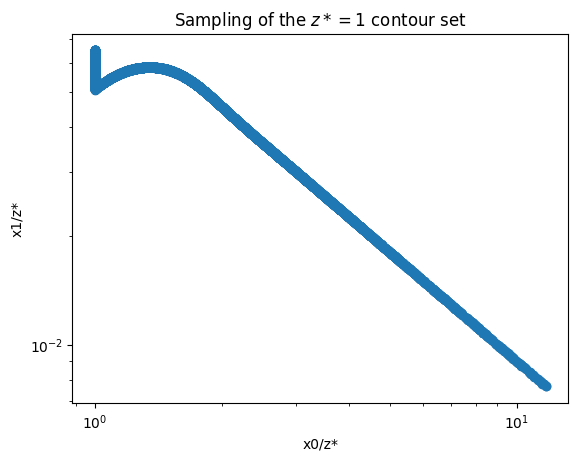

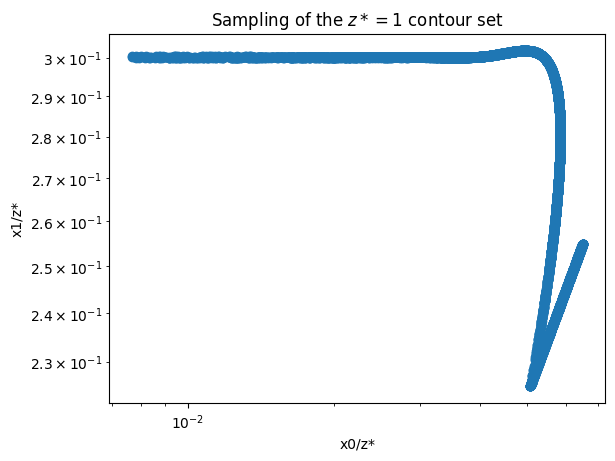

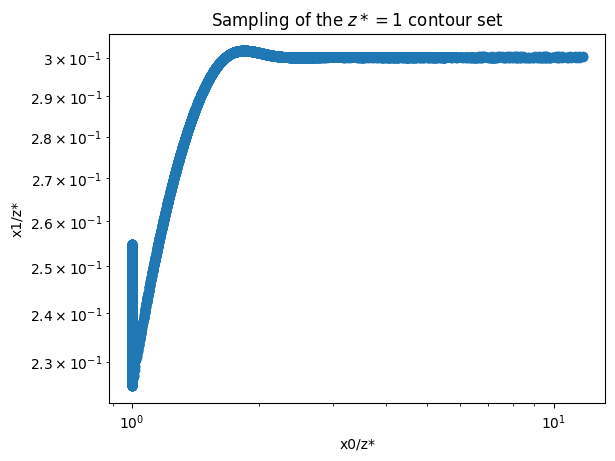

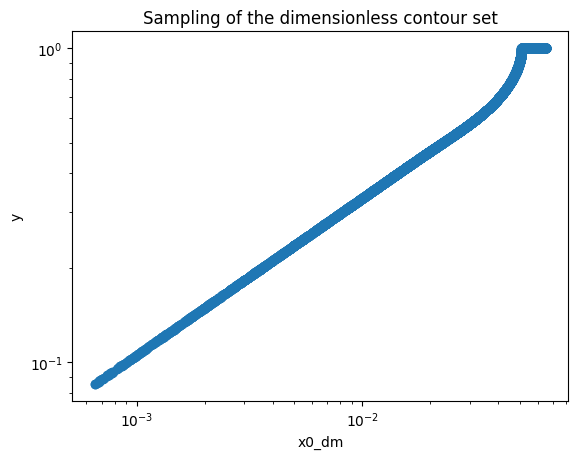

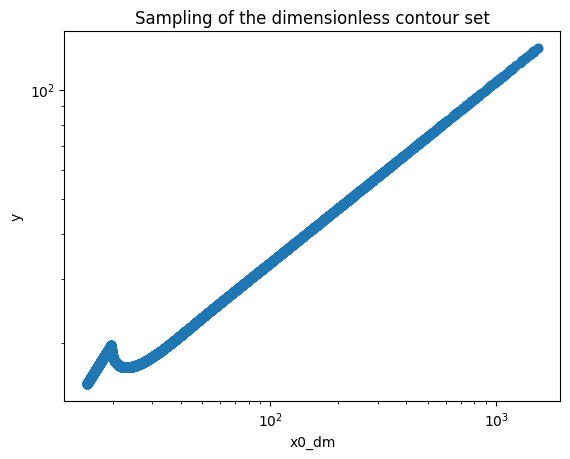

In [5]:
#1 Contours d1H Sets

def contour_d1H (data):
    plt.scatter(data['x0'], data['x1'])
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("x0/z*")
    plt.ylabel("x1/z*")
    plt.title("Sampling of the $z*=1$ contour set")
    plt.show()
    
def contour_dm (data):
    plt.scatter(data['x0'], data['y'])
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("x0_dm")
    plt.ylabel("y")
    plt.title("Sampling of the dimensionless contour set")
    plt.show()

#d1H Set 1
contour_d1H(data_d1H_1_scaled)
#d1H Set2
contour_d1H(data_d1H_2_scaled)

#d1H Set2
contour_d1H(data_d1H_3_scaled)

#DM Set 1
contour_dm(data_dm_1)
#DM Set 2
contour_dm(data_dm_2)

In [6]:
def linear_network(x0, x1, W):
    """
    Linear fit of a response variable dependent 
    on explanatory variables x0, x1 weighted by W.
    """
    
    f = W[0]*x0 + W[1]*x1
    
    return x0/f, x1/f, f

def mape(prediction, truth):
    return 100 * np.mean(np.abs((prediction - truth) / truth))

def fit_and_validate(W, data, data_scaled, network):
    """
    input:
    W           array of weights
    data        input data
    data_scaled rescaled input data
    network     a function e.g. "linear_network" implemented above
    
    output: 
    up to you..
    """

    # Predict the hypothenuse by evaluating the provided network on the provided data.
    x0, x1, f = network(data['x0'], data['x1'], W)
    # Compute the mape.
    accuracy = mape(f, data['z*'])

    # Recreate the figure with the two plots shown above
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.scatter(data_scaled.x0, data_scaled.x1, color="red", label="Data")
    ax1.scatter(x0, x1, marker="x", label="Prediction")
    ax1.set_xlabel("x0/z*")
    ax1.set_ylabel("x1/z*")
    ax1.legend()
    
    # Verify the prediction using the provided labels.
    ax2.loglog(data['z*'], f, marker="x", ls='', label="Prediction")
    # Create the diagonal line.
    z = [data['z*'].min(), data['z*'].max()]
    ax2.plot(z, z, color='r', label = "f(x,y)=d")
    # Report the error in the plot title.
    ax2.set_title(f"MAPE = {accuracy:.2f} %" )
    ax2.set_xlabel("Reference")
    ax2.set_ylabel("Prediction")
    ax2.legend()


%matplotlib inline
import ipywidgets as ip

def interactive_fit(w0, w1):
    fit_and_validate([w0, w1], data_d1H_1, data_d1H_1_scaled, linear_network)

ip.interact(interactive_fit, w0=(-0.2, 0.2, 0.001), w1=(10.00, 20.00, 0.001));

#Best at w0 = 0.18 ; w1 = 13.48 (6.12%)

interactive(children=(FloatSlider(value=0.0, description='w0', max=0.2, min=-0.2, step=0.001), FloatSlider(val…

**Generalized Linear Regression**

In [7]:
def generalized_linear_network(x0, x1, W):
    f = W[0]*x0 + W[1]*x1 + W[2] * np.sqrt(x0 * x1)
    
    return x0/f, x1/f, f

%matplotlib inline
import ipywidgets as ip

def interactive_fit(w0, w1, w2):
    fit_and_validate([w0, w1, w2], data_d1H_1, data_d1H_1_scaled, generalized_linear_network)

ip.interact(interactive_fit, w0=(-0.20, 0.20, 0.001), w1=(-1.00, 10.00, 0.01), w2=(-1.00, 5.00, 0.01));

#w0 = -0.01; w1 = 2.05; w2 = 3.20

interactive(children=(FloatSlider(value=0.0, description='w0', max=0.2, min=-0.2, step=0.001), FloatSlider(val…

## Building blocks for neural networks

In [8]:
# Network weight initialization function
# Check the assignment text for a different way to initialize your weights.

def init_weights(input_dim, output_dim):
    return np.random.uniform(-1.0, 1.0, (input_dim, output_dim))

In [9]:
def init_weights_2(input_dim, output_dim, sigma=0.1):
    return np.random.normal(0.0, sigma, (input_dim, output_dim))

In [10]:
# Activation functions

def relu(input):
    return np.maximum(0, input)

In [11]:
# Loss functions

def msre(input, target):
    return np.square((target - input) / target).mean()

In [12]:
# Predict using a trained set of model weights.

def predict(input, weights):
    [w1, w2] = weights
    return relu(input @ w1) @ w2

In [13]:
#Data split
test_d1H_1 = data_d1H_1.iloc[::5]
train_d1H_1 = data_d1H_1.drop(test_d1H_1.index)

test_dm_1 = data_dm_1.iloc[::5]
train_dm_1 = data_dm_1.drop(test_dm_1.index)

#Convert to numpy
train_np_dh = train_d1H_1.to_numpy()
test_np_dh = test_d1H_1.to_numpy()

train_np_dm = train_dm_1.to_numpy()
test_np_dm = test_dm_1.to_numpy()

print(train_np_dh)

[[3.77594704e+01 1.25461343e+00 2.29850107e+01]
 [4.79329682e+03 2.28159261e+02 3.98690302e+03]
 [2.52695524e+02 2.81336151e+00 8.88655193e+01]
 ...
 [2.42885320e+03 3.66830682e+01 9.95057284e+02]
 [2.73414556e+03 5.57446394e+01 1.29843200e+03]
 [7.88314976e+00 2.23853583e-01 4.40283139e+00]]


In [14]:
#D1H VERSION

# Function to train a simple 2-N-1 model.
# NOTE: This function expects numpy matrices for the train and test data.
#       If your train and test data is stored in pandas dataframes you 
#       can convert using the `.to_numpy()` function.


def train_model_dh(
    num_neurons, epochs, train, test, lr = 10e-5
):
    w1 = init_weights_2(2, num_neurons)
    w2 = init_weights_2(num_neurons, 1)

    train_loss = []
    test_loss = []

    for epoch in range(epochs):
        epoch_loss = 0
            
        for entry in train:

            entry = entry.reshape(1, -1) # ADDED EXTRA
            # Split the label from the input
            [x0, y] = np.split(entry, [-1], axis=1)

            # Forward pass
            z1 = x0 @ w1
            x1 = relu(z1)

            z2 = x1 @ w2

            # Compute error
            loss = msre(z2, y)
            epoch_loss += loss

            # TODO: Implement backward pass.
                #w2 = w2 - lr*np.transpose(2*(-y+z2)@x1/(y*y))
                #w1 = w1 - lr*np.transpose(x0@(np.heaviside(np.transpose(z1), 1)*w2@(-y+z2)/(y*y)))
            dz2 = 2*(-y+z2)/(y*y)
            dw2 = dz2@x1

            dx1 = w2  @ (-y+z2)/(y*y)*2
            dz1 = dx1*np.heaviside(np.transpose(z1), 0)
            dw1 = dz1 @ x0
            w1 = w1 - lr*np.transpose(dw1)
            w2 = w2 - lr*np.transpose(dw2) 
            

        #TODO: Compute total loss for the epoch
        loss_this_epoch = np.divide(epoch_loss, len(train)) # Replace nan with your code
        # Add the loss for this epoch to the list of losses
        train_loss.append(loss_this_epoch)
        
        # Compute and store test loss.
        pred = predict(test[:, :2], [w1, w2])
        test_loss.append(msre(pred[:, 0], test[:, 2]))

    return [[train_loss, test_loss], [w1, w2]]

In [15]:
#DIMENSIONLESS VERSION

# Function to train a simple 2-N-1 model.
# NOTE: This function expects numpy matrices for the train and test data.
#       If your train and test data is stored in pandas dataframes you 
#       can convert using the `.to_numpy()` function.

def train_model_dm(
    num_neurons, epochs, train, test, lr = 5e-5
):
    w1 = init_weights(2, num_neurons)
    w2 = init_weights(num_neurons + 1, 1)

    train_loss = []
    test_loss = []

    for epoch in range(epochs):
        epoch_loss = 0
            
        for entry in train:

            entry = entry.reshape(1, -1) # ADDED EXTRA
            # Split the label from the input
            [x0, y] = np.split(entry, [-1], axis=1)

            # Forward pass
            z1 = y @ w1[1:2, :] + w1[0:1, :]
            x1 = relu(z1)
            
            #z1 = x0 @ w1
            #x1 = relu(z1)

            z2 = x1 @ w2[:-1, :] + w2[-1:, :]

            # Compute error
            loss = msre(z2, y)
            epoch_loss += loss

            # TODO: Implement backward pass.
            
            dz2 = 2*(-y+z2)/(y*y)
            dw2 = x1 @ dz2 
            dw2b = dz2 
            w2[:-1, :] = w2[:-1, :] - lr*np.transpose(dw2)
            w2[-1:, :] = w2[-1:, :] - lr *np.transpose(dw2b)

            dx1 = w2[:-1, :] @ dz2            
            dz1 = dx1 * np.heaviside(np.transpose(z1), 1)                  # (1,H)
            dw1 = x0 @ dz1

        #TODO: Compute total loss for the epoch
        loss_this_epoch = np.divide(epoch_loss, len(train)) # Replace nan with your code
        # Add the loss for this epoch to the list of losses
        train_loss.append(loss_this_epoch)
        
        # Compute and store test loss.
        #pred = predict(test[:, :2], [w1, w2])
        test_loss.append(msre(pred[:, 0], test[:, 2]))

    return [[train_loss, test_loss], [w1, w2]]

In [16]:
#D1H VERSION 2

# Function to train a simple 2-N-1 model.
# NOTE: This function expects numpy matrices for the train and test data.
#       If your train and test data is stored in pandas dataframes you 
#       can convert using the `.to_numpy()` function.


def train_model_dh_2(
    num_neurons, epochs, train, test, lr = 5e-5
):
    w1 = init_weights_2(2, num_neurons)
    w2 = init_weights_2(num_neurons, 1)

    train_loss = []
    test_loss = []

    for epoch in range(epochs):
        epoch_loss = 0
            
        for entry in train:

            entry = entry.reshape(1, -1) # ADDED EXTRA
            # Split the label from the input
            [x0, y] = np.split(entry, [-1], axis=1)

            # Forward pass
            z1 = x0 @ w1
            x1 = relu(z1)

            z2 = x1 @ w2

            # Compute error
            loss = msre(z2, y)
            epoch_loss += loss

            # TODO: Implement backward pass.
                #w2 = w2 - lr*np.transpose(2*(-y+z2)@x1/(y*y))
                #w1 = w1 - lr*np.transpose(x0@(np.heaviside(np.transpose(z1), 1)*w2@(-y+z2)/(y*y)))
            dz2 = 2*(-y+z2)/(y*y)
            dw2 = x1.T @ dz2

            dx1 = dz2 @ w2.T 
            dz1 = dx1 * np.heaviside(z1, 0) 
            dw1 = x0.T @ dz1
            w2 = w2 - lr * dw2
            w1 = w1 - lr * dw1
            

        #TODO: Compute total loss for the epoch
        loss_this_epoch = np.divide(epoch_loss, len(train)) # Replace nan with your code
        # Add the loss for this epoch to the list of losses
        train_loss.append(loss_this_epoch)
        
        # Compute and store test loss.
        pred = predict(test[:, :2], [w1, w2])
        test_loss.append(msre(pred[:, 0], test[:, 2]))

    return [[train_loss, test_loss], [w1, w2]]

In [17]:
train2 = train_d1H_1.to_numpy().reshape(-1, 1, 3)
test2  = test_d1H_1.to_numpy()

In [18]:
# Function to train a simple 2-N-1 model.
# NOTE: This function expects numpy matrices for the train and test data.
#       If your train and test data is stored in pandas dataframes you 
#       can convert using the `.to_numpy()` function.

def train_model_dh_3(
    num_neurons, epochs, train, test, lr = 1e-4
):
    w1 = init_weights_2(2, num_neurons)
    w2 = init_weights_2(num_neurons, 1)

    train_loss = []
    test_loss = []

    for epoch in range(epochs):
        epoch_loss = 0
            
        for entry in train:
            # Split the label from the input
            [x0, y] = np.split(entry, [-1], axis=1)

            # Forward pass
            z1 = x0 @ w1
            x1 = relu(z1)

            z2 = x1 @ w2

            # Compute error
            loss = msre(z2, y)
            epoch_loss += loss

            # TODO: Implement backward pass.
            N = z2.size
            dz2 = (2.0 / N) * (z2 - y) / (y * y)   # dL/dz2 for MSRE

            dw2 = x1.T @ dz2                       # (num_neurons, 1)
            dx1 = dz2 @ w2.T                       # (1, num_neurons)
            dz1 = dx1 * (z1 > 0)                   # ReLU derivative
            dw1 = x0.T @ dz1                       # (2, num_neurons)

            w2 = w2 - lr * dw2
            w1 = w1 - lr * dw1

        #TODO: Compute total loss for the epoch
        loss_this_epoch = epoch_loss / len(train) # Replace nan with your code
        # Add the loss for this epoch to the list of losses
        train_loss.append(loss_this_epoch)
        
        # Compute and store test loss.
        pred = predict(test[:, :2], [w1, w2])
        test_loss.append(msre(pred[:, 0], test[:, 2]))

    return [[train_loss, test_loss], [w1, w2]]

In [19]:
#Train the model d1H
#BEST VERSION SO FAR MAYBE?
epochs = 90
[[trainloss_dh, testloss_dh], [w1_dh, w2_dh]] = train_model_dh_3(300, epochs, train2, test2)

In [20]:
def predict_all(data, weights):
    X = data.iloc[:, :2].to_numpy()    #convert pd df to numpy       
    return predict(X, weights)   
prediction_dh = predict_all(data_bench_dh, [w1_dh, w2_dh])
prediction_test = predict_all(data_d1H_1, [w1_dh, w2_dh])
#print(len(predict_dh))
#print("data_d1H_1 rows:", len(data_d1H_1))
#X = data_d1H_1.iloc[:, :2].to_numpy()
#print("X shape:", X.shape)
#prediction_np = predict(X, [w1_dh, w2_dh])
#print("pred shape:", pred.shape)

model_test = submission = pd.DataFrame({
    "id": range(len(data_d1H_1)),
    "prediction": prediction_test.ravel()
})

submission = pd.DataFrame({
    "id": range(len(data_bench_dh)),
    "prediction": prediction_dh.ravel()
})

#print(submission)
submission.to_csv("predictions.csv", index=False)
print(model_test)
#print(model_test['prediction'] - data_train['z*'])

        id   prediction
0        0   729.439644
1        1    23.878254
2        2  3986.212262
3        3    82.408861
4        4     4.938921
...    ...          ...
8995  8995   760.490602
8996  8996     1.476592
8997  8997   925.750478
8998  8998  1242.430929
8999  8999     4.457318

[9000 rows x 2 columns]


In [21]:
#len(train_np_dh)
#len(test_np_dh)
print(trainloss_dh)
print(testloss_dh)
print (predict_dh)

[np.float64(0.34060947390229396), np.float64(0.30865530363619187), np.float64(0.3053183818091859), np.float64(0.30196971155693764), np.float64(0.2985995986333561), np.float64(0.2951993606882581), np.float64(0.2917601649730182), np.float64(0.28827454559751087), np.float64(0.28473531739308755), np.float64(0.2811345946672996), np.float64(0.2774663464301513), np.float64(0.27372437416816925), np.float64(0.2699030828004995), np.float64(0.26599810678791336), np.float64(0.26200381414917484), np.float64(0.2579165621960519), np.float64(0.25373347842905053), np.float64(0.24945081339301084), np.float64(0.24506728081967863), np.float64(0.24058084823203008), np.float64(0.2359914027903748), np.float64(0.2312988653568662), np.float64(0.22650338756621408), np.float64(0.22160745748859934), np.float64(0.21661285021712418), np.float64(0.21152455693345368), np.float64(0.20634380335838812), np.float64(0.20107946245493713), np.float64(0.19573451511475704), np.float64(0.19031564755503647), np.float64(0.184834

NameError: name 'predict_dh' is not defined

In [ ]:

epochs = np.arange(len(trainloss_dh))

plt.plot(epochs, trainloss_dh, label="Train Loss")
plt.plot(epochs, testloss_dh, label="Test Loss")

plt.xlabel("Epoch")
plt.ylabel("MSRE Loss")
plt.yscale("log")
plt.legend()

plt.show()

In [ ]:
#Train the model Dimensionless
[[trainloss_dm, testloss_dm], [w1_dm, w2_dm]] = train_model_dm(2, 10, train_np_dm, test_np_dm)

In [ ]:
#Final Predict Function
predict_dh.to_csv('out.csv')

In [ ]:
# Function to visualize the learned model behavior.
#data_predicted=predict_final(data_d1H_1['x0'], data_d1H_1['x1'], ww1, ww2)

#def plot_behavior(data, pred):
    # TODO: Plot the predicted one-contour/dimensionless relation vs the truth.

In [ ]:
# TODO: Train your best neural network using sliders, grid search, or backpropagation. 
#       This network is allowed to have more than one intermediate layer.